In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from libpysal import weights
import pandas as pd

In [3]:
caminho_arquivo = "..\\data\\raw\\shape_muni.gpkg"

Carregando o mapa...
Gerando o grafo de vizinhança


C:\Users\segun\AppData\Local\Temp\ipykernel_2452\2853205402.py:7: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = weights.contiguity.Queen.from_dataframe(gdf_muni)
C:\Users\segun\Documents\GitHub\Pattern-Blue\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 1525, 3499.
  W.__init__(self, neighbors, ids=ids, **kw)


Calculando centroides para o plot...


C:\Users\segun\AppData\Local\Temp\ipykernel_2452\2853205402.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  positions = dict(zip(G.nodes, gdf_muni.geometry.centroid.apply(lambda p: (p.x, p.y))))


Plotando...
Concluído.


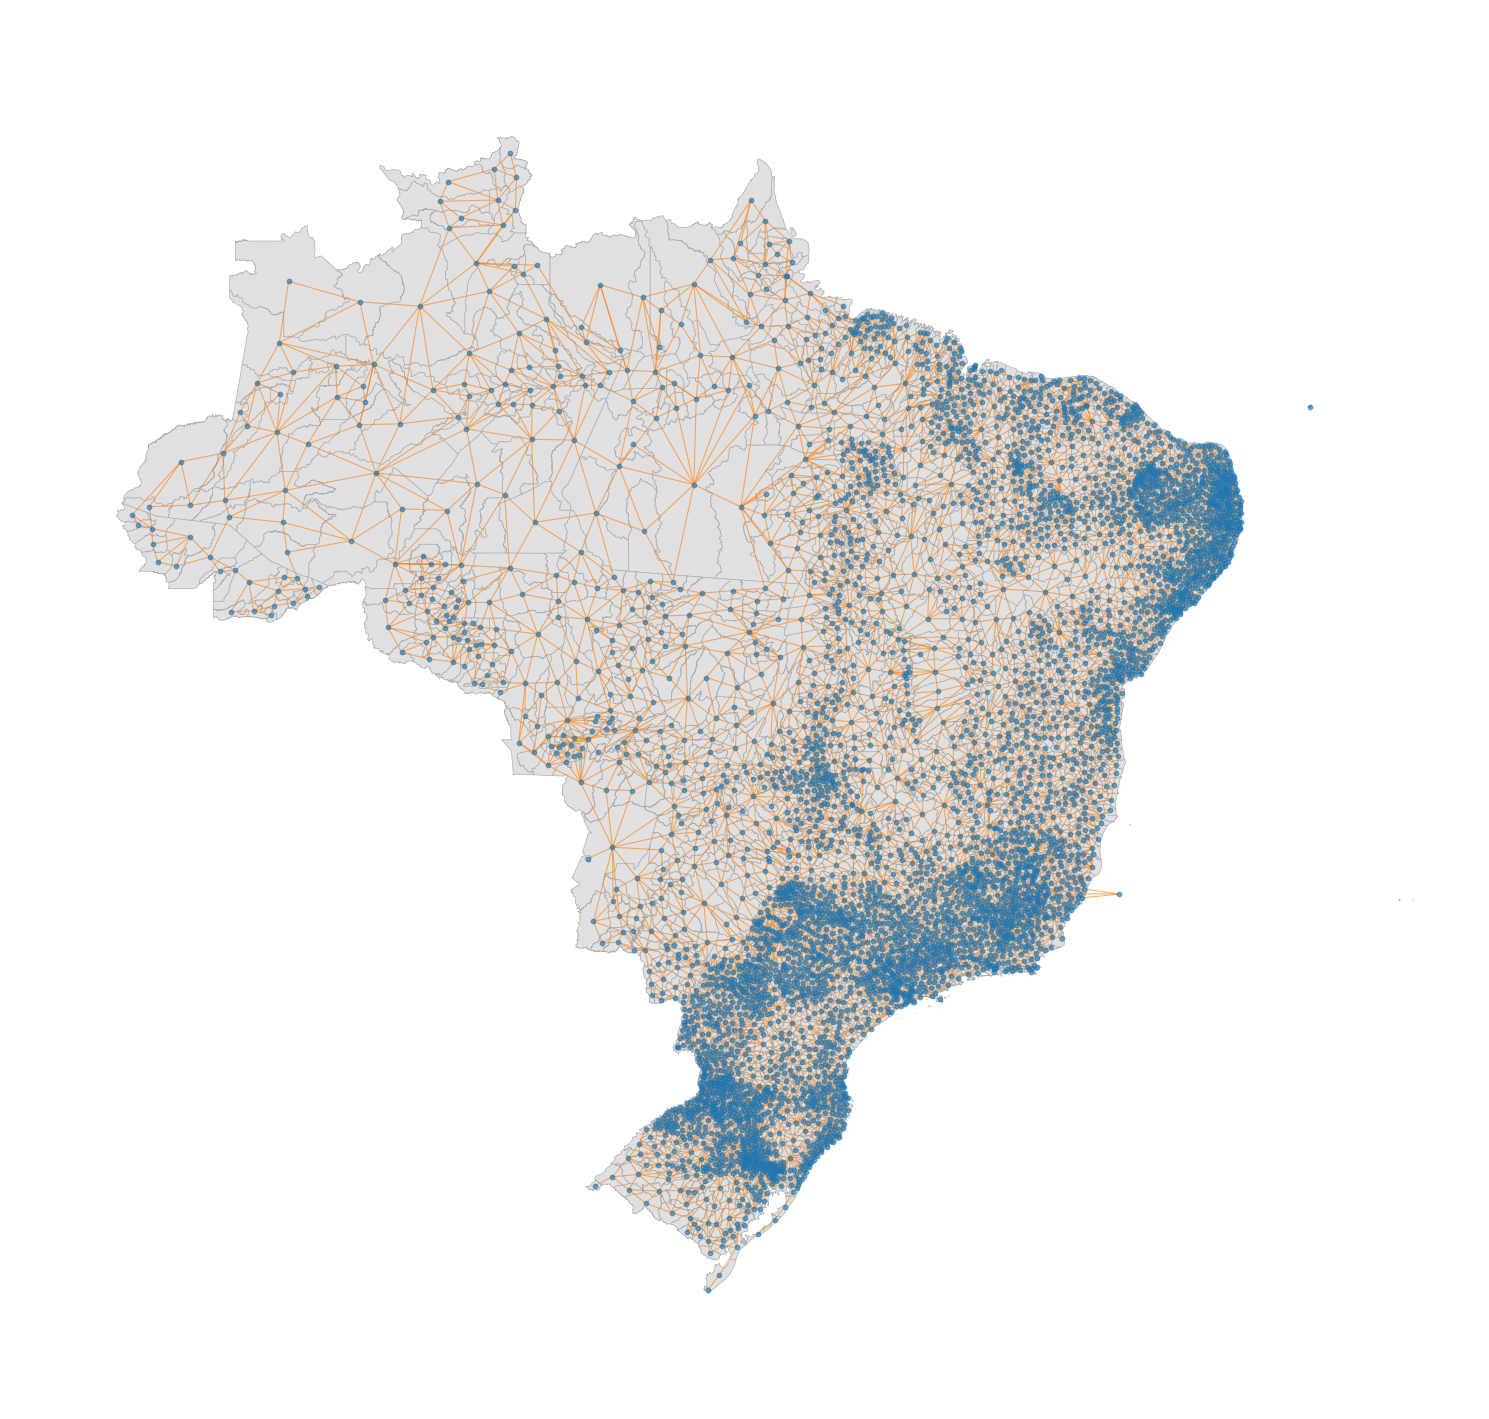

In [4]:
print("Carregando o mapa...")
gdf_muni = gpd.read_file(caminho_arquivo)

gdf_muni = gdf_muni.reset_index(drop=True)

print("Gerando o grafo de vizinhança")
w = weights.contiguity.Queen.from_dataframe(gdf_muni)

G = w.to_networkx()

print("Calculando centroides para o plot...")
positions = dict(zip(G.nodes, gdf_muni.geometry.centroid.apply(lambda p: (p.x, p.y))))

print("Plotando...")
fig, ax = plt.subplots(figsize=(15, 15)) # Tamanho grande para ver detalhes

gdf_muni.plot(
    ax=ax, 
    color='#e0e0e0',   
    edgecolor='#b0b0b0', 
    linewidth=0.5
)


nx.draw(
    G, 
    pos=positions, 
    ax=ax, 
    node_size=10,        
    node_color='#1f77b4', 
    edge_color='#ff7f0e',
    width=0.8,          
    alpha=0.6           
)

plt.title("Grafo de Conectividade Espacial: Municípios em shape_muni.gpkg", fontsize=16)
plt.axis("off") 
plt.tight_layout()

print("Concluído.")
plt.show()

In [5]:
print("Iniciando extração de métricas do grafo...")

eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)
clustering_coeff = nx.clustering(G)
degree_cent = dict(G.degree())
pagerank = nx.pagerank(G)

df_metrics = pd.DataFrame({
    'node_idx': list(G.nodes),
    'eigen_centrality': [eigen_cent[i] for i in G.nodes],
    'clustering_coeff': [clustering_coeff[i] for i in G.nodes],
    'degree_connectivity': [degree_cent[i] for i in G.nodes],
    'pagerank_score': [pagerank[i] for i in G.nodes]
})

df_metrics['geocode'] = gdf_muni.loc[df_metrics['node_idx'], 'geocode'].values

df_static_spatial = df_metrics.drop(columns=['node_idx'])

print("Métricas calculadas com sucesso.")
print(df_static_spatial.head())

Iniciando extração de métricas do grafo...
Métricas calculadas com sucesso.
   eigen_centrality  clustering_coeff  degree_connectivity  pagerank_score  \
0          0.000001          0.285714                    7        0.000235   
1          0.000001          0.285714                    7        0.000215   
2          0.000005          0.000000                    2        0.000087   
3          0.000005          0.238095                    7        0.000230   
4          0.000002          0.666667                    3        0.000125   

   geocode  
0  1100015  
1  1100023  
2  1100031  
3  1100049  
4  1100056  


In [6]:
df_static_spatial.to_parquet("../data/processed/metrics_static_spatial.parquet", index=False)

print("Métricas estáticas salvas em Parquet.")

for i, node in enumerate(G.nodes()):
    G.nodes[node]['geocode'] = str(gdf_muni.loc[node, 'geocode'])

nx.write_graphml(G, "../data/processed/grafo_municipios.graphml")

print("Grafo salvo em GraphML.")

Métricas estáticas salvas em Parquet.
Grafo salvo em GraphML.


Arquivo carregado com sucesso!
🔹 Dimensões: (5570, 5) (Linhas x Colunas)
------------------------------
Colunas encontradas:
['geocode', 'geocode_name', 'uf', 'uf_code', 'geometry']
------------------------------
Amostra dos dados:
   geocode           geocode_name  uf  uf_code  \
0  1100015  Alta Floresta D'oeste  RO       11   
1  1100023              Ariquemes  RO       11   
2  1100031                 Cabixi  RO       11   
3  1100049                 Cacoal  RO       11   
4  1100056             Cerejeiras  RO       11   

                                            geometry  
0  MULTIPOLYGON (((-61.96836 -12.13407, -61.96827...  
1  MULTIPOLYGON (((-63.18282 -10.13892, -63.18615...  
2  MULTIPOLYGON (((-60.70518 -13.32474, -60.70904...  
3  MULTIPOLYGON (((-61.3474 -11.50562, -61.34569 ...  
4  MULTIPOLYGON (((-60.82417 -13.11156, -60.82289...  


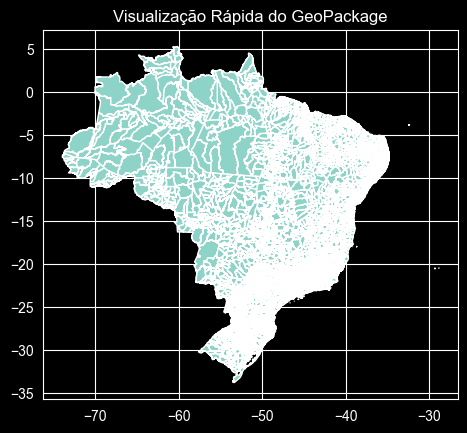

In [7]:
try:
    gdf = gpd.read_file(caminho_arquivo)

    print("Arquivo carregado com sucesso!")
    print(f"🔹 Dimensões: {gdf.shape} (Linhas x Colunas)")
    print("-" * 30)

    print("Colunas encontradas:")
    print(gdf.columns.tolist())
    print("-" * 30)

    print("Amostra dos dados:")
    print(gdf.head())

    gdf.plot()
    plt.title("Visualização Rápida do GeoPackage")
    plt.show()

except Exception as e:
    print(f"Erro ao abrir o arquivo: {e}")

In [8]:
vizinhos = gpd.sjoin(gdf, gdf, predicate='touches', how='inner')

In [9]:
vizinhos = vizinhos[vizinhos['geocode_left'] != vizinhos['geocode_right']]

In [10]:
df_edges = pd.DataFrame({
    'source_geocode': vizinhos['geocode_left'],
    'target_geocode': vizinhos['geocode_right']
})

In [11]:
degree = df_edges.groupby('source_geocode').size().reset_index(name='num_neighbors')

In [12]:
static_features = gdf[['geocode', 'geocode_name', 'uf', 'uf_code']].copy()
static_features = static_features.merge(degree, left_on='geocode', right_on='source_geocode', how='left')
static_features['num_neighbors'] = static_features['num_neighbors'].fillna(0).astype(int)

In [13]:
static_features.to_csv("../data/processed/static_features_tft.csv", index=False)
df_edges.to_csv("../data/processed/adjacencia_edges.csv", index=False)

print("Arquivos gerados com sucesso!")

Arquivos gerados com sucesso!
